In [1]:
rimport sqlite3 as sql
from multiprocessing import Pool, set_start_method
from pathlib import Path
from itertools import count


import polars as pl
import polars.selectors as cs
from rdkit import Chem, RDLogger
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
set_start_method("fork")
lg = RDLogger.logger()
lg.setLevel(RDLogger.CRITICAL)

## ChEMBL data extraction

In [3]:
CHEMBL_VERSION = 36
DATA = Path("..") / "data"
RAW = DATA / "raw"
CURATED = DATA / "curated"
CHEMBL_DB_FILE = (
    DATA
    / f"chembl_{CHEMBL_VERSION}/chembl_{CHEMBL_VERSION}_sqlite/chembl_{CHEMBL_VERSION}.db"
)

RAW.mkdir(parents=True, exist_ok=True)
CURATED.mkdir(parents=True, exist_ok=True)

assert CHEMBL_DB_FILE.exists(), f"ChEMBL database file not found at {CHEMBL_DB_FILE}"

In [4]:
conn = sql.connect(
    str(CHEMBL_DB_FILE),
    isolation_level=None,
)

This query selects activity data from ChEMBL.

In [5]:
query = """
SELECT
    a.chembl_id AS assay_chembl_id,
    a.assay_type AS assay_type,
    a.assay_organism AS assay_organism,
    a.assay_group AS assay_group,
    a.confidence_score AS assay_confidence_score,
    act.activity_id,
    -- act.chembl_id as activity_chembl_id,
    act.potential_duplicate,
    act.assay_id,
    act.doc_id AS activity_doc_id,
    a.doc_id AS assay_doc_id,
    act.standard_type,
    act.standard_value,
    act.pchembl_value,
    act.standard_units,
    act.molregno AS compound_id,
    md.chembl_id as compound_chembl_id,
    cs.canonical_smiles,
    cp.mw_freebase,
    cp.alogp,
    cp.hba,
    cp.hbd,
    cp.psa,
    cp.rtb,
    cp.num_ro5_violations,
    cp.full_mwt,
    cp.aromatic_rings,
    cp.heavy_atoms,
    cp.qed_weighted,
    cp.np_likeness_score,
    d.doc_id AS doc_id,
    d.year,
    d.authors,
    td.chembl_id as target_chembl_id,
    td.tid as target_tid
FROM activities act
JOIN assays a
    ON act.assay_id = a.assay_id
JOIN compound_structures cs
    ON act.molregno = cs.molregno
JOIN compound_properties cp
    ON cp.molregno = act.molregno
JOIN molecule_dictionary as md
    ON md.molregno = act.molregno
JOIN docs d
    ON d.doc_id = act.doc_id
JOIN target_dictionary td
    ON td.tid = a.tid
WHERE act.standard_relation = '='
"""

In [6]:
import hashlib
import json


def md5_hash(content: str) -> str:
    return hashlib.md5(content.encode()).hexdigest()


def cached_chembl_df(sql_query: str, chembl_version: int) -> pl.DataFrame:
    key = md5_hash(sql_query + f"_CHEMBL{chembl_version}")
    df_location = RAW / f"{key}.csv.gz"
    json_location = RAW / f"{key}.json"
    if not json_location.exists():
        json_location.write_text(
            json.dumps({"sql_query": sql_query, "chembl_version": chembl_version})
        )
    if df_location.exists():
        print(f"Loading cached data from {df_location}")
        return pl.read_csv(df_location)
    df = pl.read_database(sql_query, conn, infer_schema_length=None)
    try:
        df.write_csv(df_location, compression="gzip")
    except Exception as e:
        print(f"Failed to write cached data to {df_location}: {e}")
    return df

In [7]:
md5_hash(query + f"_CHEMBL{CHEMBL_VERSION}")

'ac841a5edd75b79c093db7bdff995af1'

In [8]:
df = cached_chembl_df(query, CHEMBL_VERSION)

Loading cached data from ../data/raw/ac841a5edd75b79c093db7bdff995af1.csv.gz


In [9]:
df

assay_chembl_id,assay_type,assay_organism,assay_group,assay_confidence_score,activity_id,potential_duplicate,assay_id,activity_doc_id,assay_doc_id,standard_type,standard_value,pchembl_value,standard_units,compound_id,compound_chembl_id,canonical_smiles,mw_freebase,alogp,hba,hbd,psa,rtb,num_ro5_violations,full_mwt,aromatic_rings,heavy_atoms,qed_weighted,np_likeness_score,doc_id,year,authors,target_chembl_id,target_tid
str,str,str,str,i64,i64,i64,i64,i64,i64,str,f64,f64,str,i64,str,str,f64,f64,i64,i64,f64,i64,i64,f64,i64,i64,f64,f64,i64,i64,str,str,i64
"""CHEMBL872937""","""B""",null,null,8,31864,0,83907,6432,6432,"""IC50""",2500.0,5.6,"""nM""",182268,"""CHEMBL324340""","""Cc1ccc2oc(-c3cccc(N4C(=O)c5ccc…",398.37,4.3,5,1,100.71,3,0,398.37,4,30,0.52,-1.35,6432,2004,"""Courtney SM, Hay PA, Buck RT, …","""CHEMBL3921""",11653
"""CHEMBL872937""","""B""",null,null,8,31866,0,83907,6432,6432,"""IC50""",9000.0,5.05,"""nM""",182855,"""CHEMBL109600""","""COc1ccccc1-c1ccc2oc(-c3ccc(OC)…",520.5,5.68,7,1,119.17,6,2,520.5,5,39,0.28,-0.87,6432,2004,"""Courtney SM, Hay PA, Buck RT, …","""CHEMBL3921""",11653
"""CHEMBL760688""","""B""",null,null,8,31868,0,154606,6570,6570,"""IC50""",4000.0,5.4,"""nM""",252199,"""CHEMBL357278""","""Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=…",543.01,4.27,7,2,77.93,8,1,543.01,3,36,0.44,-2.2,6570,2004,"""Koltun DO, Marquart TA, Shenk …","""CHEMBL4632""",10483
"""CHEMBL623452""","""A""","""Homo sapiens""",null,0,31869,0,5080,6570,6570,"""% remaining""",25.0,null,"""%""",252199,"""CHEMBL357278""","""Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=…",543.01,4.27,7,2,77.93,8,1,543.01,3,36,0.44,-2.2,6570,2004,"""Koltun DO, Marquart TA, Shenk …","""CHEMBL612558""",22224
"""CHEMBL760688""","""B""",null,null,8,31870,0,154606,6570,6570,"""IC50""",17000.0,4.77,"""nM""",253534,"""CHEMBL357119""","""Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=…",468.62,2.32,7,2,77.93,10,0,468.62,3,33,0.48,-1.73,6570,2004,"""Koltun DO, Marquart TA, Shenk …","""CHEMBL4632""",10483
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""CHEMBL5739541""","""B""","""Homo sapiens""",null,9,29054631,0,2596842,135925,135925,"""kon""",null,null,null,3238772,"""CHEMBL6021771""","""CC(C)Oc1cc2c(OC[C@@H]3CCC(=O)N…",436.47,2.13,6,3,136.4,7,0,436.47,3,32,0.52,-0.37,135925,2023,null,"""CHEMBL3778""",19639
"""CHEMBL5739541""","""B""","""Homo sapiens""",null,9,29054632,0,2596842,135925,135925,"""k_off""",null,null,"""s-1""",3238772,"""CHEMBL6021771""","""CC(C)Oc1cc2c(OC[C@@H]3CCC(=O)N…",436.47,2.13,6,3,136.4,7,0,436.47,3,32,0.52,-0.37,135925,2023,null,"""CHEMBL3778""",19639
"""CHEMBL5739541""","""B""","""Homo sapiens""",null,9,29054633,1,2596842,135925,135925,"""IC50""",503.0,6.3,"""nM""",3195979,"""CHEMBL5978978""","""Cc1nccc(-c2cnc(OC[C@@H]3CCC(=O…",435.48,2.54,7,2,129.32,7,0,435.48,3,32,0.58,-0.62,135925,2023,null,"""CHEMBL3778""",19639


In [10]:
df.columns

['assay_chembl_id',
 'assay_type',
 'assay_organism',
 'assay_group',
 'assay_confidence_score',
 'activity_id',
 'potential_duplicate',
 'assay_id',
 'activity_doc_id',
 'assay_doc_id',
 'standard_type',
 'standard_value',
 'pchembl_value',
 'standard_units',
 'compound_id',
 'compound_chembl_id',
 'canonical_smiles',
 'mw_freebase',
 'alogp',
 'hba',
 'hbd',
 'psa',
 'rtb',
 'num_ro5_violations',
 'full_mwt',
 'aromatic_rings',
 'heavy_atoms',
 'qed_weighted',
 'np_likeness_score',
 'doc_id',
 'year',
 'authors',
 'target_chembl_id',
 'target_tid']

# Curation

In [11]:
df.group_by("standard_type").agg(
    (pl.len() / df.shape[0]).alias("proportion"),
    pl.len().alias("count"),
    pl.n_unique("assay_chembl_id").alias("assay_count"),
).sort("proportion", descending=True).head(100).write_csv("top100.csv")

In [12]:
# keep track of how the percentage of data we discard
# across these data types
TRACKED_STANDARD_TYPES = [
    "IC50",
    "Percent Effect",
    "Inhibition",
    "Potency",
    # "k_off",
    # "k_on",
    "Activity",
    "Ki",
    "MIC",
    "EC50",
    "INHIBITION",
]


# helper class for monitoring the effect of curation steps on the size and makeup of the dataset
class Curation:
    description_factors = [
        pl.when(pl.col.standard_type.is_in(TRACKED_STANDARD_TYPES))
        .then(pl.col.standard_type)
        .otherwise(pl.lit("other"))
        .alias("standard_type_")
    ]
    description_items = [
        pl.len().alias("measurements"),
        pl.n_unique("compound_chembl_id").alias("compounds"),
        pl.n_unique("assay_chembl_id").alias("assays"),
        pl.len()
        .over("assay_chembl_id")
        .quantile(0.25)
        .alias("lower_quartile_assay_size"),
        pl.len().over("assay_chembl_id").median().alias("median_assay_size"),
        pl.len()
        .over("assay_chembl_id")
        .quantile(0.75)
        .alias("upper_quartile_assay_size"),
    ]

    def __init__(self, data: pl.DataFrame):
        self.data = data
        self.step_counter = count()
        self.summary = self._describe_data().with_columns(
            pl.lit("raw").alias("step_name"),
            pl.lit(next(self.step_counter)).alias("step_index"),
        )

    def _describe_data(self) -> pl.DataFrame:
        return self.data.group_by(self.description_factors).agg(*self.description_items)

    def step(self, callable):
        def _wrapped_step(*arg, **kwargs):
            self.data = callable(self.data, *arg, **kwargs)
            summary = self._describe_data().with_columns(
                pl.lit(callable.__name__).alias("step_name"),
                pl.lit(next(self.step_counter)).alias("step_index"),
            )
            self.summary = pl.concat((self.summary, summary))

        return _wrapped_step

    def plot_summary(self, standard_type_on_cols: bool = False, facet_over="row"):
        sns.set_style("whitegrid")

        def _fractional(col: pl.Expr | str, over="standard_type_"):
            if isinstance(col, str):
                col = pl.col(col)
            return col / col.max().over(over)

        sb_col = "standard_type_"
        sb_hue = "entity"
        if not standard_type_on_cols:
            sb_col, sb_hue = sb_hue, sb_col

        facet_over = "col" if standard_type_on_cols else facet_over
        facet_kwarg = {facet_over: sb_col}
        height = 3 if standard_type_on_cols else 4.5

        long_summary = self.summary.select(
            "standard_type_",
            _fractional("measurements"),
            _fractional("compounds"),
            _fractional("assays"),
            pl.col.step_index.cast(int),
            "step_name",
        ).unpivot(
            on=["measurements", "compounds", "assays"],
            variable_name="entity",
            value_name="fraction",
            index=["standard_type_", "step_index", "step_name"],
        )

        totals = (
            self.summary.select(
                "standard_type_",
                "measurements",
                "compounds",
                "assays",
                pl.col.step_index.cast(int),
                "step_name",
            )
            .unpivot(
                on=["measurements", "compounds", "assays"],
                variable_name="entity",
                value_name="count",
                index=["standard_type_", "step_index", "step_name"],
            )
            # aggregate over standard types
            # to get total counts
            .group_by("entity", "step_index")
            .agg(
                pl.col.count.sum(),
                pl.col.step_name.first(),
            )
            # convert counts to fractions in [0, 1]
            .with_columns(
                (pl.col.count / pl.col.count.max().over("entity")).alias("fraction")
            )
        )

        g = sns.FacetGrid(
            long_summary,
            hue=sb_hue,
            col_wrap=3 if standard_type_on_cols else None,
            aspect=0.85 + 0.15 * long_summary.n_unique("step_index"),
            height=height,
            **facet_kwarg,
        )
        g.map_dataframe(
            sns.lineplot, x="step_index", y="fraction", marker="o", linestyle="--"
        )
        g.set_titles("{%s_name}" % facet_over)
        if not standard_type_on_cols:
            for ax in g.axes.flatten():
                sns.barplot(
                    totals.filter(entity=ax.get_title()),
                    x="step_index",
                    y="fraction",
                    color="black",
                    alpha=0.2,
                    width=1.0,
                    label="total",
                    legend=False,
                    edgecolor="black",
                    ax=ax,
                )
        for ax in g.axes.flatten():
            ax.set_xticks(range(long_summary["step_index"].max() + 1))
        g.set_xticklabels(
            long_summary.select("step_index", "step_name")
            .unique()
            .sort("step_index", descending=False)["step_name"]
            .to_list(),
            step=1,
            rotation=-45,
        )
        if standard_type_on_cols:
            g.add_legend(
                loc="upper center", ncols=3, bbox_to_anchor=(0.4, 1.05), title="none"
            )
        else:
            top = 1.1 if facet_over == "row" else 1.3
            g.add_legend(
                loc="upper center",
                title="Standard Type",
                ncols=4,
                bbox_to_anchor=(0.33, top),
            )
        g.set_titles("unique {%s_name}" % facet_over)
        sns.despine(left=True)


curation = Curation(df)

NOTE
- ignore assay_group field: not used, only present in few data (0.14% of rows)
- split by authors or document?

## Step: remove measurements flagged as potential duplicates
This flag is provided directly by ChEMBL, and is based on the [following criteria](https://chembl.gitbook.io/chembl-interface-documentation/frequently-asked-questions/chembl-data-questions#can-you-provide-more-details-on-how-to-detect-potentially-duplicated-data):

> We detect and flag duplicated activity entries and potential transcription errors in activity records that come from publications.

> The former are records with identical compound, target, activity, 
> type and unit values that were most likely reported as citations of measurements from previous papers, even when these measurements were subsequently rounded. 

> The latter cases consist of otherwise identical entries whose activity values differ by exactly 3 or 6 orders of magnitude indicating a likely error in the units (e.g. uM instead of nM).

In [13]:
@curation.step
def duplicates(df: pl.DataFrame):
    return df.filter(pl.col.potential_duplicate == 0)


duplicates()

## Step: remove measurements where `standard_value` is null

In [14]:
@curation.step
def null_values(df: pl.DataFrame):
    return df.filter(pl.col.standard_value.is_not_null())


null_values()

## Step: remove invalid SMILES
We remove invalid SMILES, which are defined as those that
- cannot be parsed by rdkit
- contain ".", to guarantee that we only have single compounds (i.e. no mixtures or salts)

In [15]:
unique_smiles = curation.data.select(
    pl.col.canonical_smiles, pl.col.compound_chembl_id
).unique()


def is_valid_smiles(smi: str) -> bool:
    return ("." not in smi) and (Chem.MolFromSmiles(smi) is not None)


with Pool(12) as pool:
    mask = list(
        pool.imap(is_valid_smiles, unique_smiles["canonical_smiles"].to_list()),
    )

In [16]:
valid_smiles = unique_smiles.filter(pl.Series(mask))


@curation.step
def invalid_smiles(df: pl.DataFrame):
    return df.join(valid_smiles, on=pl.col.compound_chembl_id, how="inner")


invalid_smiles()


## Data grouping by assay, measurement type, and document
ChEMBL data groups naturally by `assay_chembl_id` into more or less homogeneous groups.
Some of these groups are still subject to different standard types/units and may aggregate measurements from different documents, which may indicate different experimental conditions.
To increase group homogenity, we further split these groups by the following fields:
- `standard_type`
- `standard_units`
- `activity_doc_id`

This makes the activity values more comparable within each such group since the same type and unit of measurement is used, and the same document is cited (which should indicate similar experimental conditions).

In [17]:
REFINED_ASSAY = "assay_x_type_x_doc"
curation.data = curation.data.with_columns(
    pl.concat_str(
        pl.col.assay_chembl_id,
        pl.col.standard_type,
        pl.col.standard_units,
        pl.col.activity_doc_id,
        separator="_",
    ).alias(REFINED_ASSAY)
)

## Step: remove repeated measurements (intra-assay duplicates)
Some groups contain repeated measurements for the same compound, which we remove by keeping only the median value for each compound within each group.

In [18]:
import polars.selectors as cs

activity_cols = cs.by_name(["standard_value", "pchembl_value"])
remaining_cols = cs.all() - activity_cols
from_repeated_measurements = pl.len() - 1


@curation.step
def repeated_measurements(df: pl.DataFrame) -> pl.DataFrame:
    return df.group_by(REFINED_ASSAY, "compound_chembl_id").agg(
        activity_cols.median(),
        remaining_cols.first(),
        from_repeated_measurements.alias("from_repeated_measurements"),
    )


repeated_measurements()

In [19]:
frac = (curation.data["from_repeated_measurements"] > 1).mean()
print(
    f"{frac:.2%} of remaining measurements are medians from repeated measurements (i.e. intra-assay duplicates)"
)

1.33% of remaining measurements are medians from repeated measurements (i.e. intra-assay duplicates)


## Step: filter by assay size

In [20]:
assay_sizes = curation.data.group_by(REFINED_ASSAY).agg(pl.len().alias("size"))
assay_sizes.select("size").describe(percentiles=[0.5, 0.7, 0.8, 0.9])

statistic,size
str,f64
"""count""",1.229623e6
"""null_count""",0.0
"""mean""",8.587268
"""std""",522.926146
"""min""",1.0
"""50%""",2.0
"""70%""",3.0
"""80%""",6.0
"""90%""",13.0


Lots of assays, after also grouping by document and measurement type, have very few measurements.

In [21]:
print(1 - (assay_sizes["size"] >= 5).mean())

0.7547963888118554


75\% of homogenized assays have less than 5 measurements!

### Drop very large and very small assays

In [22]:
min_assay_size = 5
max_assay_size = 2048


@curation.step
def small_assays(df: pl.DataFrame):
    return df.filter(
        pl.len().over(REFINED_ASSAY) >= min_assay_size,
    )


@curation.step
def large_assays(df: pl.DataFrame):
    return df.filter(
        pl.len().over(REFINED_ASSAY) <= max_assay_size,
    )


small_assays()
large_assays()

## Transform target
We want to use pchembl values when availabe and standard value otherwise.

In [23]:
# some activity types are very likely to support pchembl values
curation.data.group_by("standard_type").agg(
    pl.len().alias("size"),
    (1 - pl.col.pchembl_value.null_count() / pl.len()).alias("pchembl_density"),
).filter(pl.col.pchembl_density > 0).sort("size", descending=True).head(10)

standard_type,size,pchembl_density
str,u32,f64
"""IC50""",2010558,0.941306
"""Ki""",449129,0.975829
"""EC50""",313820,0.954044
"""Kd""",58425,0.957261
"""AC50""",57974,0.98439
"""ED50""",47654,0.050804
"""Potency""",36041,0.989234
"""XC50""",25,1.0


In [24]:
# other activity types are incompatible with the concept of pchembl values and have none of them
curation.data.group_by("standard_type").agg(
    pl.len().alias("size"),
    (1 - pl.col.pchembl_value.null_count() / pl.len()).alias("pchembl_density"),
).filter(pl.col.pchembl_density == 0).sort("size", descending=True).head(10)

standard_type,size,pchembl_density
str,u32,f64
"""Inhibition""",564135,0.0
"""MIC""",432495,0.0
"""Activity""",354490,0.0
"""GI50""",108526,0.0
"""IZ""",75828,0.0
"""Residual Activity""",73944,0.0
"""GI""",73066,0.0
"""CC50""",41550,0.0
"""CL""",38817,0.0


**Takeaway**: pchembl is almost always available for IC50, Ki, KD, EC50, but not for other prominent types such as Inhibition, MIC, Activity, ...

#### Caveat: pchembl value always or never available intra-assay?
A special case we need to consider are assays where some measurements have pchembl values and others don't.

In [25]:
(
    curation.data.group_by(REFINED_ASSAY)
    .agg(pl.col.pchembl_value.is_not_null().n_unique().alias("target_inconsistency"))
    .select("target_inconsistency")
    > 1
).mean()

target_inconsistency
f64
0.048925


This is the case for nearly 5% of our assay groups (see cell above).

### Solution: use pchembl when all entries in an assay have it, otherwise use standard_value

In [26]:
pchembl_is_available = pl.col.pchembl_value.is_not_null()
is_pchembl_assay = pchembl_is_available.all().over(REFINED_ASSAY)

curation.data = curation.data.with_columns(
    pl.when(is_pchembl_assay)
    .then(pl.col.pchembl_value)
    .otherwise(pl.col.standard_value)
    .alias("target_transformed"),
    pl.when(is_pchembl_assay)
    .then(pl.lit("pchembl_value"))
    .otherwise(pl.lit("standard_value"))
    .alias("target_transformed_type"),
)

## Steps: drop assays with low activity range


### Few unique values
If an assay has very few unique values, it is likely that the measurements are not sufficiently diverse to be informative for modeling. We can filter out assays where the number of unique values is below some threshold (e.g. 3).

In [27]:
@curation.step
def few_uniques(df: pl.DataFrame) -> pl.DataFrame:
    unique_y = pl.col.target_transformed.n_unique().over(REFINED_ASSAY)
    return df.filter(unique_y >= 3)


few_uniques()

### Low  pchembl range
When pchembl values are available, we can use known margin of errors from the literature to filter out assays where the range of values is too small.

References on margin of error for pchembl values:
- Kalliokoski et al. (PLoS ONE, 2013)
- Nelen et al. (Journal of Cheminformatics, 2025)

A generally accepted margin of error for pchembl values is 0.5 log units, i.e. when two compounds from the same assay have pchembl values that differ by less than 0.5, it is difficult to say with confidence that one compound is more active than the other.

By sorting activities in an assay, the number of pairs which differ by at least some threshold $\epsilon$ can be compputed in logarithmic time (see below).

In [28]:
def epsilon_pairs(y: pl.Expr | str, eps: float) -> pl.Expr:
    """
    Returns a polars expression that computes the fraction of pairs of values in y that differ by at least eps.
    """
    if isinstance(y, str):
        y = pl.col(y)
    y_sorted = y.sort()
    n = pl.len()
    # return the fraction of pairs that differ by at least eps
    return (
        2
        * (n - y_sorted.search_sorted(y_sorted + eps, side="right")).sum()
        / (n * (n - 1))
    )


In [29]:
# can use the epsilon pairs in a group_by context:
dummy_data = {"y": [1, 2, 3] + [3, 1, 2, 1, 4], "group": list("A" * 3 + "B" * 5)}
dummy_data = pl.DataFrame(dummy_data)
dummy_data.group_by("group").agg(epsilon_pairs(pl.col("y"), eps=1))

group,literal
str,f64
"""B""",0.5
"""A""",0.333333


In [30]:
# or compute the epsilon pairs directly over group columns (similar to pandas group_by/transform)
dummy_data.with_columns(epsilon_pairs(pl.col("y"), eps=1).over("group"))

y,group,literal
i64,str,f64
1,"""A""",0.333333
2,"""A""",0.333333
3,"""A""",0.333333
3,"""B""",0.5
1,"""B""",0.5
2,"""B""",0.5
1,"""B""",0.5
4,"""B""",0.5


For pchembl assays we consider a pair of compounds to be distinguishable if their pchembl values differ by at least 0.5 log units.

We drop pchembl assays if less than 20% of compound pairs are not distinguishable by this criterion.

In [31]:
pchembl_reliability = 0.5
required_distinguishable_fraction = 0.2
is_pchembl_assay = pchembl_is_available.all().over(REFINED_ASSAY)


@curation.step
def pchembl_range(df: pl.DataFrame):
    return df.filter(
        # keep all non-pchembl assays for now
        is_pchembl_assay.not_()
        | (
            epsilon_pairs("pchembl_value", eps=pchembl_reliability).over(REFINED_ASSAY)
            >= required_distinguishable_fraction
        )
    )


pchembl_range()

### Low MIC range
For MIC it is generally accepted that a single doubling is within the margin of error, so we can filter out assays where all values are within a single doubling, i.e. those with less than three unique values.

Note that MIC is reported in varying units. We focus on mug/ml and nM which together cover >98% of ChEMBL MIC measurements (see below).

In [32]:
curation.data.filter(pl.col.standard_type == "MIC").group_by("standard_units").agg(
    (
        (
            pl.len().alias("percent")
            / curation.data.filter(pl.col.standard_type == "MIC").shape[0]
        )
        * 100
    ).round(2)
).sort("percent", descending=True)

standard_units,percent
str,f64
"""ug.mL-1""",82.55
"""nM""",16.31
"""10'-2 umol/ml""",0.48
"""ug""",0.19
"""ug cm**-2""",0.08
…,…
"""ug disk-1""",0.0
"""ug m1 l-1""",0.0
"""ng""",0.0


We convert nM to mug/ml using the molecular weight of the compound (full_mwt field in ChEMBL).

We then convert concentrations in mug/ml to log2 scale, where 1 log2 unit corresponds to one doubling.

Similarly to pchembl, we consider compounds to be distinguishable if their log2 MIC values differ more than 1 log2 unit, and we drop assays where less than 20% of compound pairs are distinguishable by this criterion.

In [33]:
conv_mugml = pl.col.full_mwt.mul(10 ** (-6)).mul(pl.col.standard_value)
y = pl.col.target_transformed


@curation.step
def mic_range(df: pl.DataFrame):
    # remove MIC with weird standard units
    df = df.filter(
        (pl.col.standard_type != "MIC")
        | (pl.col.standard_units.is_in(["ug.mL-1", "nM"]))
    )
    # set target_transformed to negative log2 for concentration values
    df = df.with_columns(
        pl.when((pl.col.standard_type == "MIC") & (pl.col.standard_units == "ug.mL-1"))
        .then(pl.col.standard_value.clip(lower_bound=1e-9).log(base=2).neg() + 10)
        .when((pl.col.standard_type == "MIC") & (pl.col.standard_units == "nM"))
        .then(conv_mugml.clip(lower_bound=1e-9).log(base=2).neg() + 10)
        .otherwise("target_transformed")
        .alias("target_transformed"),
        pl.when((pl.col.standard_type == "MIC") & (pl.col.standard_units == "ug.mL-1"))
        .then(pl.lit("pmic"))
        .when((pl.col.standard_type == "MIC") & (pl.col.standard_units == "nM"))
        .then(pl.lit("pmic_nm"))
        .otherwise("target_transformed_type")
        .alias("target_transformed_type"),
    )
    df = df.filter(
        (pl.col.standard_type != "MIC")
        | (epsilon_pairs("target_transformed", eps=1.1).over(REFINED_ASSAY) >= 0.2)
    )
    return df


mic_range()

### Low percent inhibition/activity range
Note that most "Inhibition" and "Activity" measurements are reported in percent inhibition or percent activity, respectively.

TODO add references on margin of error for percent inhibition/activity values.

We use 10% as a margin of error for percent inhibition/activity values, and we drop assays where less than 20% of compound pairs are distinguishable by this criterion.

In [34]:
y = pl.col.target_transformed
is_percentage_value = pl.col.standard_type.is_in(
    ["Inhibition", "Activity", "Percent Effect", "Residual Activity"]
) & (pl.col.standard_units == "%")


@curation.step
def percentage_range(df: pl.DataFrame):
    return df.filter(
        is_percentage_value.not_()
        | (epsilon_pairs("target_transformed", eps=10).over(REFINED_ASSAY) >= 0.2)
    )


percentage_range()

### Conditional log10 transformation of standard values
When standard values in an assay are heavily skewed or span several orders of magnitude, we log10 transform them to obtain a distribution that is more amenable to modeling.


In [35]:
y = pl.col.standard_value
assay_skew = y.skew().over(REFINED_ASSAY)
assay_dyn_range = y.max().over(REFINED_ASSAY) / y.min().over(REFINED_ASSAY).clip(1e-8)
assay_size = pl.len().over(REFINED_ASSAY)
non_negativity = y.min().over(REFINED_ASSAY) >= 0

# no need to do this if pchembl is available or the target was already transformed
is_standard_values = pl.col.target_transformed_type == "standard_value"

required_samples = 10
skew_threshold = 1.0
range_threshold = 1e3

condition = (
    is_standard_values
    & non_negativity
    & (assay_size >= required_samples)
    & ((assay_skew.abs() >= skew_threshold) | (assay_dyn_range >= range_threshold))
)
transformed = (
    pl.when(condition)
    .then(pl.col.target_transformed.clip(lower_bound=1e-9).log(base=10))
    .otherwise(pl.col.target_transformed)
)
transformed_type = (
    pl.when(condition)
    .then(pl.lit("log10_transformed"))
    .otherwise(pl.col.target_transformed_type)
)

curation.data = curation.data.with_columns(
    transformed.alias("target_transformed"),
    transformed_type.alias("target_transformed_type"),
)

In [36]:
curation.data.group_by("target_transformed_type").agg(
    (pl.len() / curation.data.shape[0]).alias("proportion"),
    pl.len().alias("size"),
).sort("size", descending=True)

target_transformed_type,proportion,size
str,f64,u32
"""pchembl_value""",0.445671,2229283
"""standard_value""",0.271429,1357710
"""log10_transformed""",0.20692,1035031
"""pmic""",0.063275,316508
"""pmic_nm""",0.012705,63554


### Low "everything else" range

Assays of misc types are filtered based on the standard deviation and coefficient of variation (CV) of the standard_values.
The CV is a unitless measure of variability (standard deviation divided by mean).
We drop assays where the CV is below 0.2, i.e. where the standard deviation is less than 20% of the mean, or where the standard deviation is very small in absolute terms.

In [ ]:
y = pl.col.target_transformed
std = y.std().over(REFINED_ASSAY)
mean = y.mean().over(REFINED_ASSAY)
has_tiny_std = std < 1e-6
has_small_cv = (std / mean) < 0.2


@curation.step
def general_range(df: pl.DataFrame):
    # we want to apply the "misc assay type" filter exclusively to data that has not been processed
    # by the previous activity range filters
    retain = is_pchembl_assay | is_percentage_value | (pl.col.standard_type == "MIC")
    # apply filter
    df = df.filter(retain | (has_tiny_std | has_small_cv).not_())
    return df


general_range()

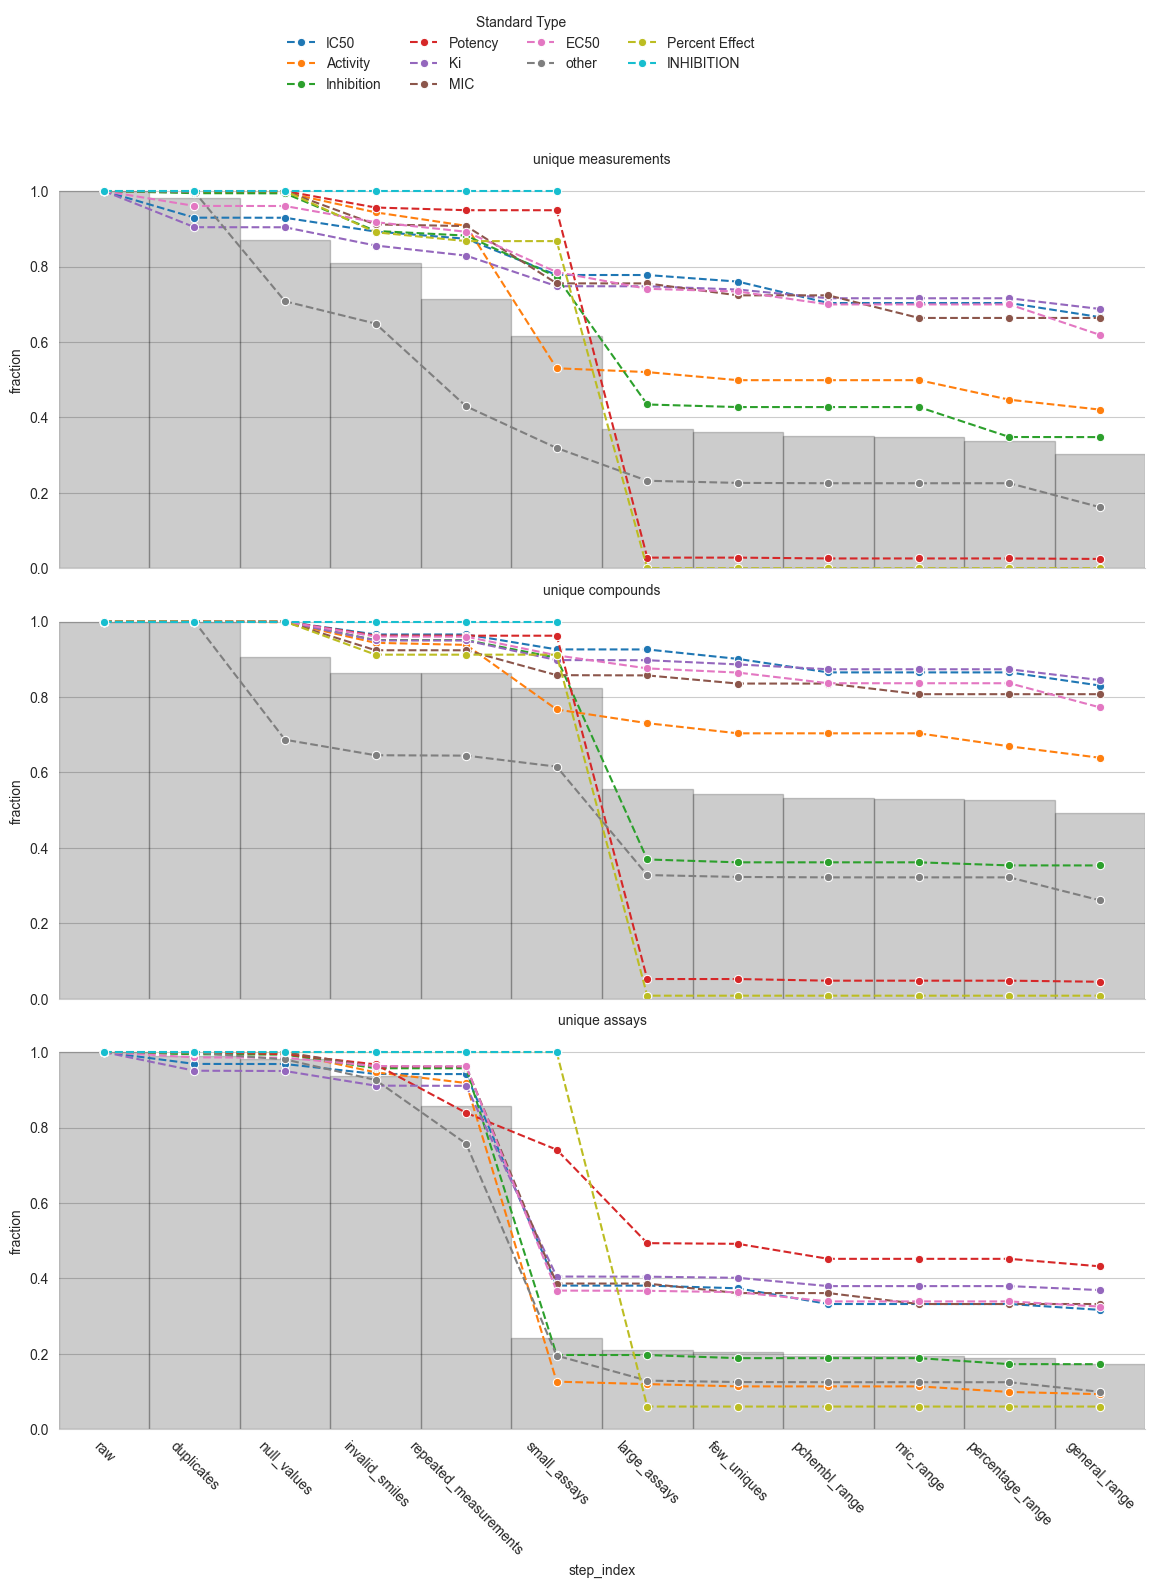

In [ ]:
curation.plot_summary()

/var/folders/gp/_kdyh3hn1yv47p6w56krv9000000gn/T/ipykernel_57511/1856371499.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


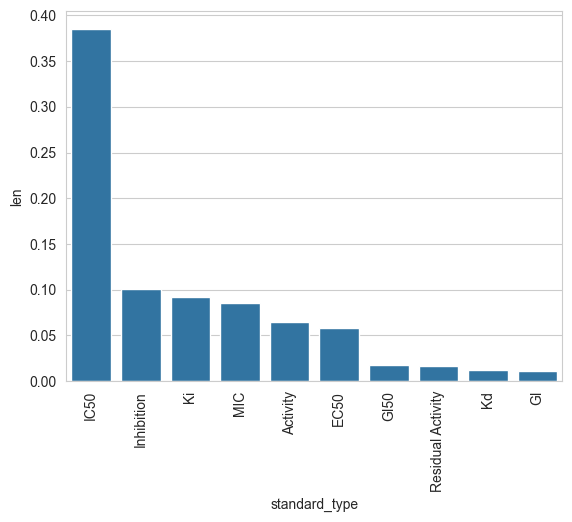

In [ ]:
ax = sns.barplot(
    curation.data.group_by("standard_type")
    .agg(pl.len() / curation.data.shape[0])
    .filter(pl.col.len >= 0.01)
    .sort("len", descending=True),
    x="standard_type",
    y="len",
)
_ = ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

/var/folders/gp/_kdyh3hn1yv47p6w56krv9000000gn/T/ipykernel_57511/4025228310.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


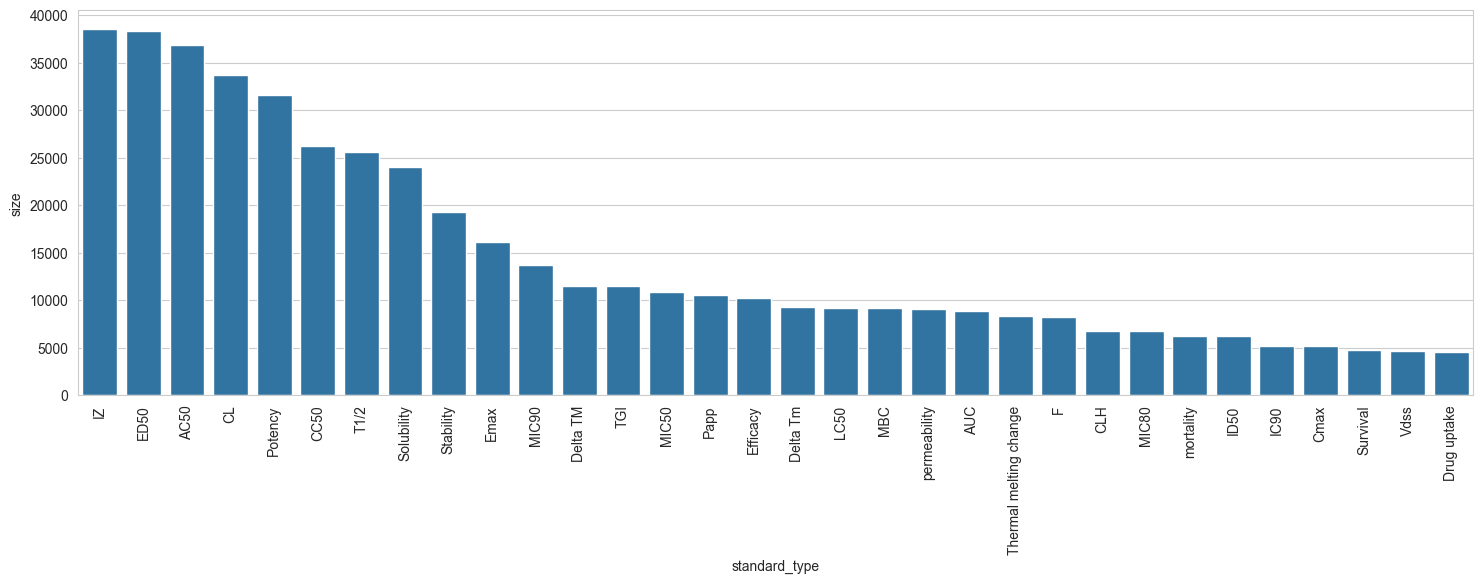

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))
ax = sns.barplot(
    curation.data.group_by("standard_type")
    .agg(pl.len() / curation.data.shape[0], pl.len().alias("size"))
    .filter(pl.col.len > 0.001, pl.col.len <= 0.01)
    .sort("len", descending=True),
    x="standard_type",
    y="size",
)
_ = ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

In [ ]:
curation.data.group_by(REFINED_ASSAY).agg(pl.col.standard_type.first()).group_by(
    "standard_type"
).agg(pl.len().alias("count")).sort("count", descending=True).head(10)

standard_type,count
str,u32
"""IC50""",79479
"""MIC""",26308
"""Activity""",21627
"""Inhibition""",20348
"""Ki""",19984
"""EC50""",13741
"""GI50""",8092
"""GI""",4064
"""ED50""",3467


In [ ]:
curated = curation.data

### How are measurements distributed across assay sizes?

In [ ]:
import numpy as np

assay_size = pl.len().over(REFINED_ASSAY)
thresholds = [10, 20, 50, 100, 250, 500, 1000]
group_expr = pl.when(assay_size < thresholds[0]).then(pl.lit(f"[5, {thresholds[0]})"))
for lower, upper in zip(thresholds[:-1], thresholds[1:]):
    group_expr = group_expr.when((assay_size >= lower) & (assay_size < upper)).then(
        pl.lit(f"[{lower}, {upper})")
    )

standard_type_ = (
    pl.when(pl.col.standard_type.is_in(TRACKED_STANDARD_TYPES))
    .then(pl.col.standard_type)
    .otherwise(pl.lit("other"))
).alias("type")
group_expr = group_expr.otherwise(pl.lit(f"[{thresholds[-1]}, ∞)")).alias("group_size")
group_expr = group_expr.alias("group_size")
grouped = curation.data.group_by(group_expr, standard_type_).agg(
    pl.len().alias("rows"),
    (assay_size.min() // 5) * 5,
    pl.n_unique(REFINED_ASSAY).alias("assays"),
)
grouped = grouped.unpivot(
    ["rows", "assays"],
    index=["group_size", "len", "type"],
    value_name="count",
    variable_name="entity",
)

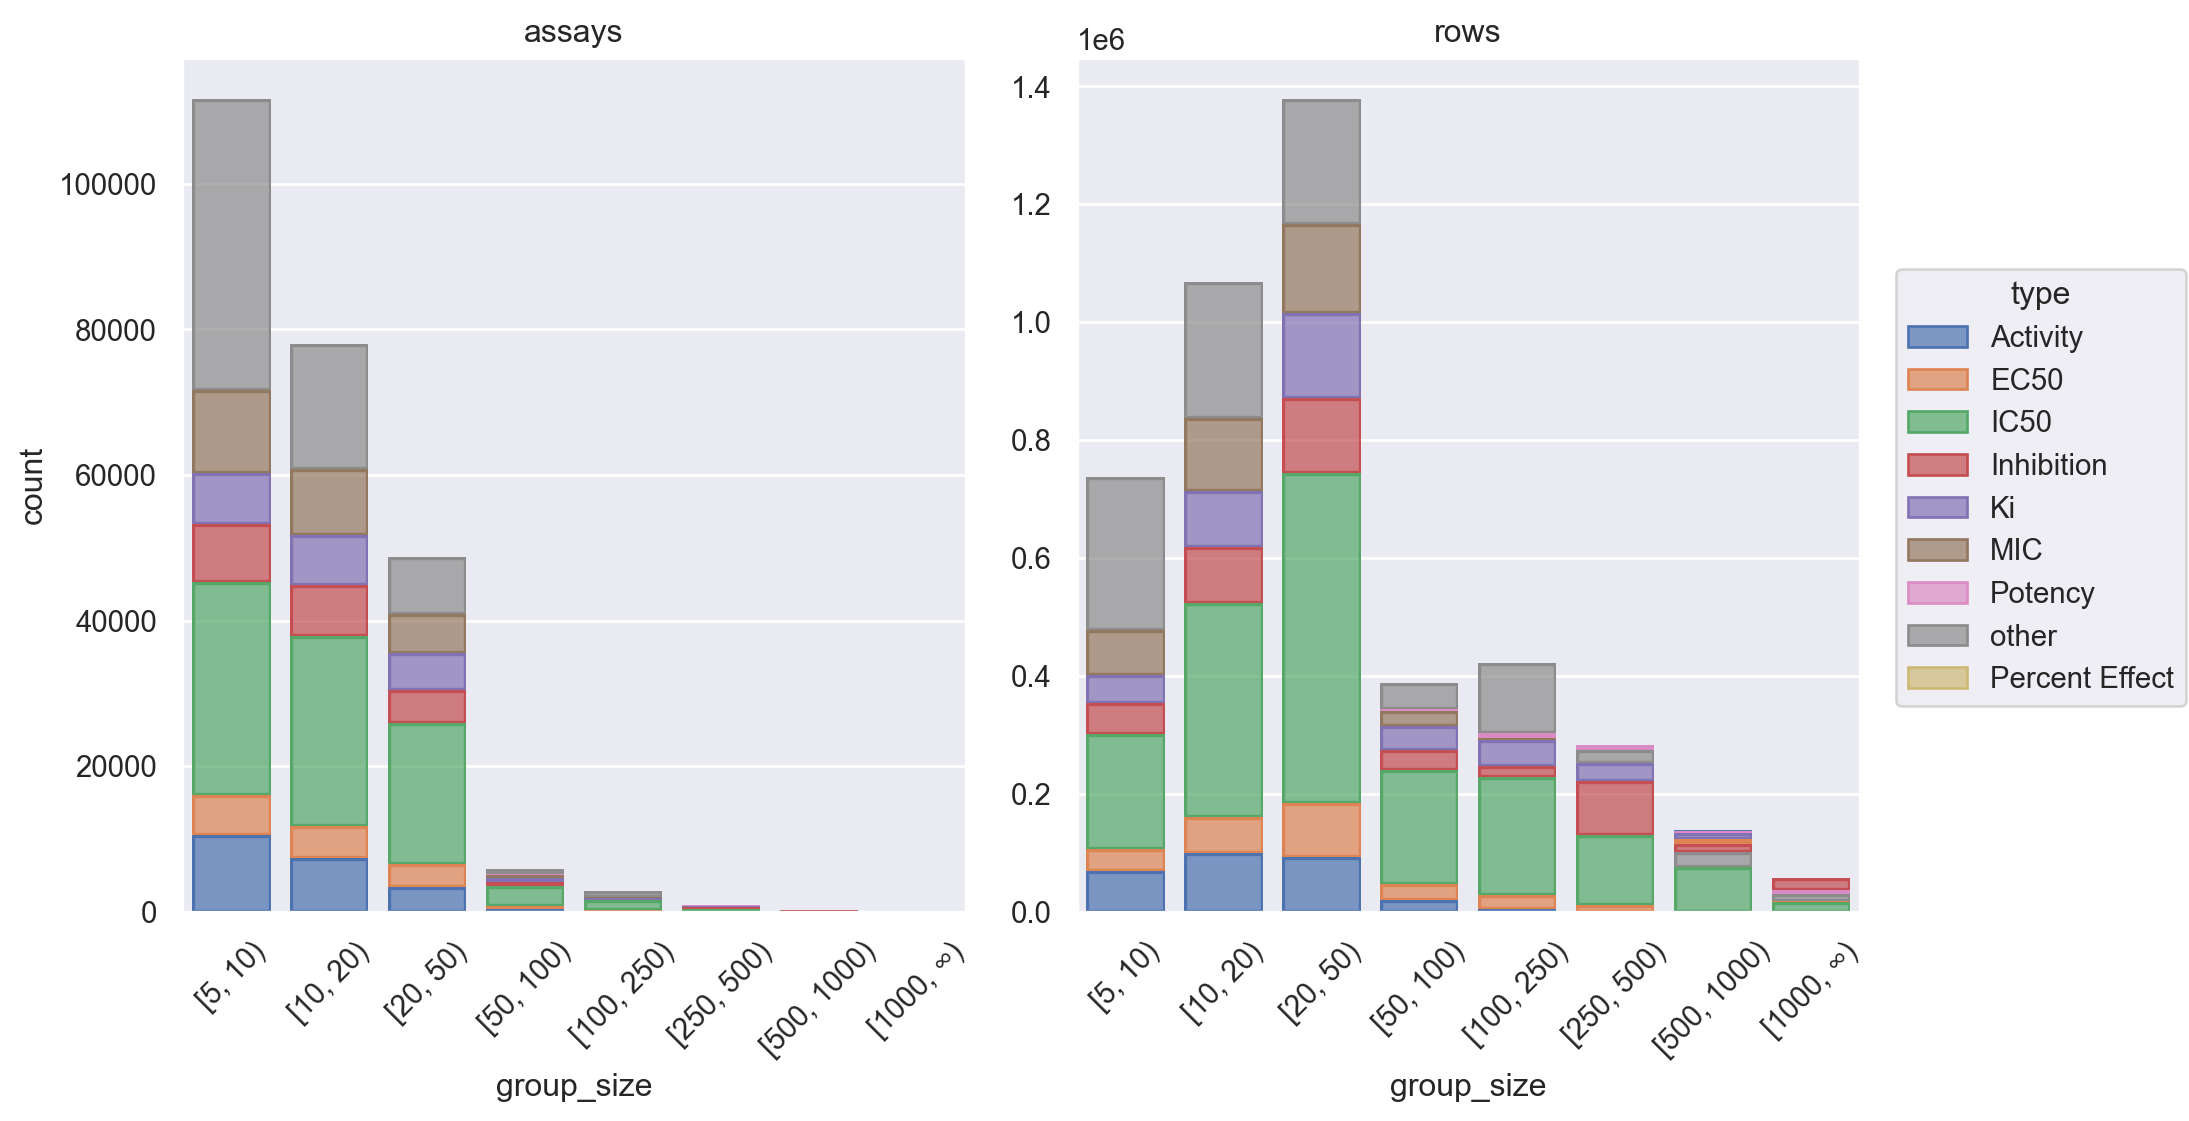

In [ ]:
import seaborn.objects as so


p = (
    so.Plot(grouped.sort("len", "type"), x="group_size", y="count", color="type")
    .add(so.Bar(), so.Stack())
    .facet("entity")
    .share(y=False)
    .layout(size=(10, 6))
    .plot()
)
for ax in p._figure.axes:
    ax.tick_params(axis="x", labelrotation=45)
p

## Mark test samples
- Randomly assigns a fraction (`frac`) of rows within a group as test samples.  
- Ensures at least one test sample per group.  
- Adds a boolean column `test`.  

In [ ]:
def mark_test_samples(
    group: str,
    test_frac: float = 0.2,
    min_test_samples: int = 1,
    seed: int = 42,
) -> pl.Expr:
    return pl.int_range(0, pl.len()).shuffle(seed=seed).over(group) < (
        pl.len().over(group) * test_frac
    ).clip(lower_bound=min_test_samples)


In [ ]:
dummy_data.with_columns(mark_test_samples("group").alias("test"))

y,group,test
i64,str,bool
1,"""A""",false
2,"""A""",false
3,"""A""",true
3,"""B""",false
1,"""B""",false
2,"""B""",false
1,"""B""",false
4,"""B""",true


In [ ]:
curated = curated.with_columns(mark_test_samples(REFINED_ASSAY).alias("test"))

In [ ]:
curated.group_by(REFINED_ASSAY).agg(pl.col.test.cast(int).sum()).min()

assay_x_type_x_doc,test
str,i64
"""CHEMBL1000057_Inhibition_%_416…",1


In [ ]:
curated["test"].mean()

0.2219238405168915

## Set `int` group identifiers

In [ ]:
group_int_ids = (
    curated.select(REFINED_ASSAY)
    .unique()
    .sort(REFINED_ASSAY)
    .with_columns(pl.int_range(0, pl.len()).alias("group"))
)
curated = curated.join(group_int_ids, on=REFINED_ASSAY, how="inner")
curated

assay_x_type_x_doc,compound_chembl_id,standard_value,pchembl_value,assay_chembl_id,assay_type,assay_organism,assay_group,assay_confidence_score,activity_id,potential_duplicate,assay_id,activity_doc_id,assay_doc_id,standard_type,standard_units,compound_id,canonical_smiles,mw_freebase,alogp,hba,hbd,psa,rtb,num_ro5_violations,full_mwt,aromatic_rings,heavy_atoms,qed_weighted,np_likeness_score,doc_id,year,authors,target_chembl_id,target_tid,canonical_smiles_right,from_repeated_measurements,target_transformed,target_transformed_type,test,group
str,str,f64,f64,str,str,str,str,i64,i64,i64,i64,i64,i64,str,str,i64,str,f64,f64,i64,i64,f64,i64,i64,f64,i64,i64,f64,f64,i64,i64,str,str,i64,str,u32,f64,str,bool,i64
"""CHEMBL2061148_IC50_nM_62680""","""CHEMBL2058800""",870.0,6.06,"""CHEMBL2061148""","""B""","""Homo sapiens""",null,9,10955488,0,829708,62680,62680,"""IC50""","""nM""",1354565,"""O=C(OC(CCCc1cccnc1)CCCc1cccnc1…",606.57,5.99,7,1,109.69,12,2,606.57,3,40,0.25,-0.48,62680,2012,"""Gopalakrishnan R, Kozany C, Wa…","""CHEMBL1902""",80,"""O=C(OC(CCCc1cccnc1)CCCc1cccnc1…",0,6.06,"""pchembl_value""",false,44260
"""CHEMBL4815472_Ki_nM_120292""","""CHEMBL4848026""",33113.11,4.48,"""CHEMBL4815472""","""B""","""Homo sapiens""",null,9,23175412,0,2106797,120292,120292,"""Ki""","""nM""",2541797,"""COc1ccc(C(C)NC(=O)/N=C(\N)NCCC…",390.51,2.35,5,4,127.65,7,0,390.51,2,27,0.33,-1.14,120292,2021,"""Biselli S, Bresinsky M, Tropma…","""CHEMBL264""",10280,"""COc1ccc(C(C)NC(=O)/N=C(\N)NCCC…",0,4.48,"""pchembl_value""",false,149579
"""CHEMBL5581844_IC50_nM_130080""","""CHEMBL5591933""",11.6,7.94,"""CHEMBL5581844""","""F""","""Homo sapiens""",null,0,26027833,0,2477351,130080,130080,"""IC50""","""nM""",2927389,"""COc1cc(S(=O)(=O)N(C)c2ccc3c(c2…",418.47,2.84,7,0,87.07,7,0,418.47,3,29,0.55,-0.94,130080,2024,"""Fuentes-Martín R, Ayuda-Durán …","""CHEMBL612545""",22226,"""COc1cc(S(=O)(=O)N(C)c2ccc3c(c2…",0,7.94,"""pchembl_value""",false,176052
"""CHEMBL5730474_IC50_nM_131319""","""CHEMBL3929399""",3160.0,5.5,"""CHEMBL5730474""","""B""","""Homo sapiens""",null,0,26673125,0,2587775,131319,131319,"""IC50""","""nM""",2138770,"""C[C@H](O)CN1CCN(c2ccc(Nc3ncc4c…",490.61,2.48,9,3,111.44,5,0,490.61,3,36,0.5,-0.86,131319,2016,null,"""CHEMBL612545""",22226,"""C[C@H](O)CN1CCN(c2ccc(Nc3ncc4c…",0,5.5,"""pchembl_value""",false,179152
"""CHEMBL5737157_IC50_nM_134758""","""CHEMBL5903827""",0.9,9.05,"""CHEMBL5737157""","""B""","""Homo sapiens""",null,7,28448129,0,2594458,134758,134758,"""IC50""","""nM""",3120828,"""CC1=Nc2c(F)cc(-c3nc(Nc4ccc(CN5…",503.6,5.23,7,1,69.54,5,2,503.6,3,37,0.51,-0.99,134758,2021,null,"""CHEMBL2111448""",104965,"""CC1=Nc2c(F)cc(-c3nc(Nc4ccc(CN5…",0,9.05,"""pchembl_value""",false,182516
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""CHEMBL5738512_IC50_nM_135452""","""CHEMBL5797725""",424.0,6.37,"""CHEMBL5738512""","""B""",null,null,8,28813199,0,2595813,135452,135452,"""IC50""","""nM""",3014726,"""CN1CC(COc2nc(N3CC4CCC(C3)N4)c3…",547.03,4.44,7,1,83.48,5,1,547.03,4,39,0.4,-0.69,135452,2022,null,"""CHEMBL2189121""",105451,"""CN1CC(COc2nc(N3CC4CCC(C3)N4)c3…",0,6.37,"""pchembl_value""",true,183132
"""CHEMBL4308761_Emax_%_110443""","""CHEMBL4582324""",220.0,null,"""CHEMBL4308761""","""B""","""Homo sapiens""",null,9,18861392,0,1809402,110443,110443,"""Emax""","""%""",2452755,"""COc1ccc2c(C(=O)Nc3ccc(NC(=O)c4…",622.73,5.65,8,3,134.89,6,2,622.73,5,46,0.22,-1.73,110443,2019,"""O'Malley DP, Ahuja V, Fink B, …","""CHEMBL2803""",12214,"""COc1ccc2c(C(=O)Nc3ccc(NC(=O)c4…",0,220.0,"""standard_value""",false,125230
"""CHEMBL905093_Inhibition_%_3582…","""CHEMBL224808""",61.3,null,"""CHEMBL905093""","""F""","""Human gammaherpesvirus 4""",null,1,1884193,0,436788,35822,35822,"""Inhibition""","""%""",379137,"""C[C@@H]1[C@@H](O)CC[C@]23C[C@]…",446.72,5.94,3,3,60.69,5,1,446.72,0,32,0.49,3.52,35822,2007,"""Kikuchi T, Akihisa T, Tokuda H…","""CHEMBL613124""",50518,"""C[C@@H]1[C@@H](O)CC[C@]23C[C@]…",0,61.3,"""standard_value""",false,232259


## Sanity checks

In [ ]:
curated.group_by(pl.col.target_transformed_type).agg(
    count=pl.len(),
    null_count=pl.col.target_transformed.null_count(),
    inf_count=pl.col.target_transformed.is_infinite().sum(),
)

target_transformed_type,count,null_count,inf_count
str,u32,u32,u32
"""log10_transformed""",625729,0,0
"""pchembl_value""",2229283,0,0
"""standard_value""",1237199,0,0
"""pmic""",316508,0,0
"""pmic_nm""",63554,0,0


## Store result

### Full curated set

In [ ]:
curated.write_csv(
    CURATED / f"chembl{CHEMBL_VERSION}_curated.csv.gz", compression="gzip"
)

### Development set

In [ ]:
assay_sample = (
    curated.select("group").unique(maintain_order=True).sample(fraction=0.2, seed=42)
)
curated.join(assay_sample, on="group", how="inner").write_csv(
    CURATED / f"chembl{CHEMBL_VERSION}_curated_sample.csv.gz", compression="gzip"
)


### Affinity subset

In [ ]:
curated.filter(
    pl.col.standard_type.is_in(["Ki", "Kd", "IC50", "EC50"]),
    pl.col.target_transformed_type == "pchembl_value",
).write_csv(
    CURATED / f"chembl{CHEMBL_VERSION}_binding_pchembl.csv.gz", compression="gzip"
)

In [ ]:
curated

NameError: name 'curated' is not defined